# Aggregate energy-distance p-value tables

Reads `pval_edist_full.csv` from each production dataset's `energy_distance/` run directory and stacks them into one long TSV. All upstream columns (`cell_count`, `type`, the 20 permutation `distance_*`/`pval_*` pairs, and the `*_mean` aggregates) are preserved.

**Input:** `datasets/<dataset_id>/<run_label>/energy_distance/pval_edist_full.csv`  
**Output:** `results/aggregate_pvals/pvals_long.tsv`

Identity columns: `dataset_id`, `dataset_short`, `run_label`, `target_id`.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path("/cellar/users/aklie/projects/tf_perturb_seq")
sys.path.append(str(PROJECT_ROOT / "config"))
from loader import load_colors

DATASETS = PROJECT_ROOT / "datasets"
EDIST = PROJECT_ROOT / "docs/jamborees/2026_UTSW/working_groups/wg1_data_qc/edist"
OUT_DIR = EDIST / "results" / "aggregate_pvals"
OUT_DIR.mkdir(parents=True, exist_ok=True)

GENE_LOOKUP = PROJECT_ROOT / "ref/genome/IGVFFI9573KOZR.gene_id_to_symbol.tsv"

dataset_colors = load_colors("production_TF-Perturb-seq", "dataset_colors")

# (dataset_id, run_label, short_name) — canonical production runs per README
RUNS = [
    ("Hon_WTC11-cardiomyocyte-differentiation_TF-Perturb-seq",          "2026_04_19_no_spacer",      "HonCM"),
    ("Huangfu_HUES8-definitive-endoderm-differentiation_TF-Perturb-seq", "muddy_penguin",            "HuangfuDE"),
    ("Huangfu_HUES8-embryonic-stemcell-differentiation_TF-Perturb-seq",  "sceptre_v1",               "HuangfuESC"),
    ("Gersbach_WTC11-hepatocyte-differentiation_TF-Perturb-seq",         "sara_synapse_syn74842722", "GersbachHep"),
]
DATASET_ORDER = [s for _, _, s in RUNS]
SHORT_TO_FULL = {s: d for d, _, s in RUNS}
COLORS = {s: dataset_colors[SHORT_TO_FULL[s]] for s in DATASET_ORDER}

print(f"OUT_DIR: {OUT_DIR}")


The history saving thread hit an unexpected error (DatabaseError('database disk image is malformed')).History will not be written to the database.


OUT_DIR: /cellar/users/aklie/projects/tf_perturb_seq/docs/jamborees/2026_UTSW/working_groups/wg1_data_qc/edist/results/aggregate_pvals


In [2]:
frames = []
for dataset_id, run_label, short in RUNS:
    p = DATASETS / dataset_id / run_label / "energy_distance" / "pval_edist_full.csv"
    if not p.is_file():
        print(f"  [skip] {short}: missing {p.relative_to(PROJECT_ROOT)}")
        continue
    df = pd.read_csv(p, index_col=0)
    df.index.name = "target_id"
    df = df.reset_index()
    df.insert(0, "dataset_short", short)
    frames.append(df)
    print(f"  {short:<12} {run_label:<28}  targets={len(df):>5}  cols={len(df.columns)}")

if not frames:
    raise SystemExit("no pval_edist_full.csv files found")

long = pd.concat(frames, ignore_index=True)
print(f"\ncombined: {len(long):,} rows × {len(long.columns)} cols")
long[["dataset_short", "target_id", "type", "cell_count", "distance_mean", "pval_mean"]].head()


  HonCM        2026_04_19_no_spacer          targets= 2030  cols=48
  HuangfuDE    muddy_penguin                 targets= 2267  cols=48
  HuangfuESC   sceptre_v1                    targets= 2267  cols=48
  GersbachHep  sara_synapse_syn74842722      targets= 2258  cols=48

combined: 8,822 rows × 48 cols


,dataset_short,target_id,type,cell_count,distance_mean,pval_mean
0,HonCM,ENSG00000090861|chr16:70289409-70289495,positive control,5,289.967438,0.14930
1,HonCM,ENSG00000177697|chr11:832818-833060,positive control,2000,1.399374,0.29895
2,HonCM,ENSG00000205981|chr3:180989327-180989725,positive control,2000,1.387793,0.25645
3,HonCM,ENSG00000186184|chr13:27621865-27621958,positive control,12,44.233057,0.84965
4,HonCM,non-targeting|1|non-targeting:1-1,negative control,2000,0.751517,0.65925


In [3]:
# Join Ensembl gene symbol from the GENCODE v43 lookup, then save the slim table.
gene_map = pd.read_csv(GENE_LOOKUP, sep="\t", usecols=["gene_id", "gene_name"]).drop_duplicates("gene_id")
long["gene_id"]     = long["target_id"].str.split("|").str[0].str.split(".").str[0]
long["gene_symbol"] = long["gene_id"].map(dict(zip(gene_map["gene_id"], gene_map["gene_name"]))).fillna("")

cols = ["dataset_short", "target_id", "gene_id", "gene_symbol",
        "type", "cell_count", "distance_mean", "pval_mean"]
out = OUT_DIR / "energy_distance_pvals_long.tsv"
long[cols].to_csv(out, sep="\t", index=False)
print(f"wrote {out.relative_to(EDIST)}  ({len(long):,} rows × {len(cols)} cols)")
print(f"unmatched gene_ids: {(long['gene_symbol'] == '').sum()} / {len(long):,}")
long[cols].head()


wrote results/aggregate_pvals/energy_distance_pvals_long.tsv  (8,822 rows × 8 cols)
unmatched gene_ids: 400 / 8,822


,dataset_short,target_id,gene_id,gene_symbol,type,cell_count,distance_mean,pval_mean
0,HonCM,ENSG00000090861|chr16:70289409-70289495,ENSG00000090861,AARS1,positive control,5,289.967438,0.14930
1,HonCM,ENSG00000177697|chr11:832818-833060,ENSG00000177697,CD151,positive control,2000,1.399374,0.29895
2,HonCM,ENSG00000205981|chr3:180989327-180989725,ENSG00000205981,DNAJC19,positive control,2000,1.387793,0.25645
3,HonCM,ENSG00000186184|chr13:27621865-27621958,ENSG00000186184,POLR1D,positive control,12,44.233057,0.84965
4,HonCM,non-targeting|1|non-targeting:1-1,non-targeting,,negative control,2000,0.751517,0.65925


In [4]:
# Quick per-dataset, per-class breakdown
summary = (long.groupby(["dataset_short", "type"])
                .agg(n_targets=("target_id", "size"),
                     n_sig_pval_05=("pval_mean", lambda s: (s < 0.05).sum()),
                     median_distance_mean=("distance_mean", "median"))
                .round(3))
summary


n_targets  n_sig_pval_05  median_distance_mean
dataset_short type                                                            
GersbachHep   negative control        100             76                 8.466
              positive control          4              3                16.908
              targeting              2154           1524                 6.952
HonCM         negative control        100              6                 1.084
              positive control          4              0                22.816
              targeting              1926            269                 1.312
HuangfuDE     negative control        100            100                91.704
              positive control          4              4                77.010
              targeting              2163           2163                93.210
HuangfuESC    negative control        100            100               528.254
              positive control          4              4               499.579
              targeting              2163           2163               527.330

## Per-dataset p-value cutoff sweeps

For each dataset, sweep p-value cutoffs and count targets crossing each — split into **targeting** (blue) and **NC** (orange). Right panel: % NCs among the hits (a per-cutoff false-positive rate from the controls). Mirrors the existing benchmark figure for Gersbach Hep.


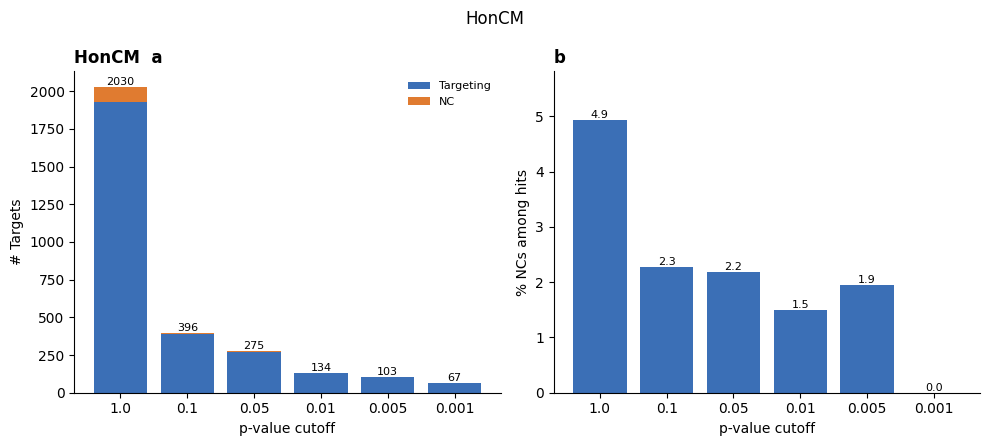

wrote cutoff_sweep_HonCM.{pdf,png}


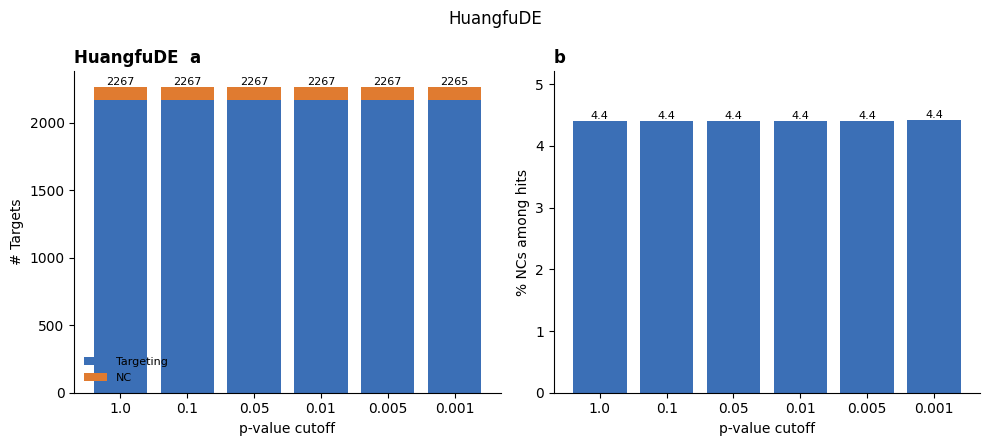

wrote cutoff_sweep_HuangfuDE.{pdf,png}


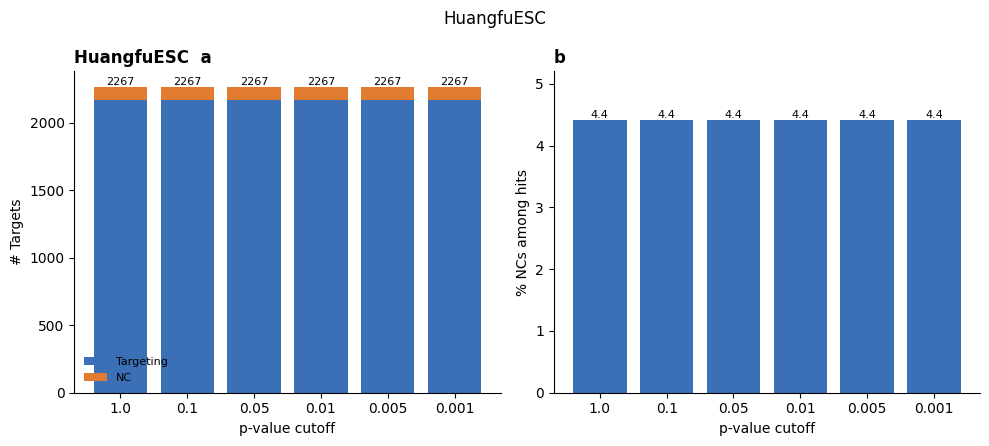

wrote cutoff_sweep_HuangfuESC.{pdf,png}


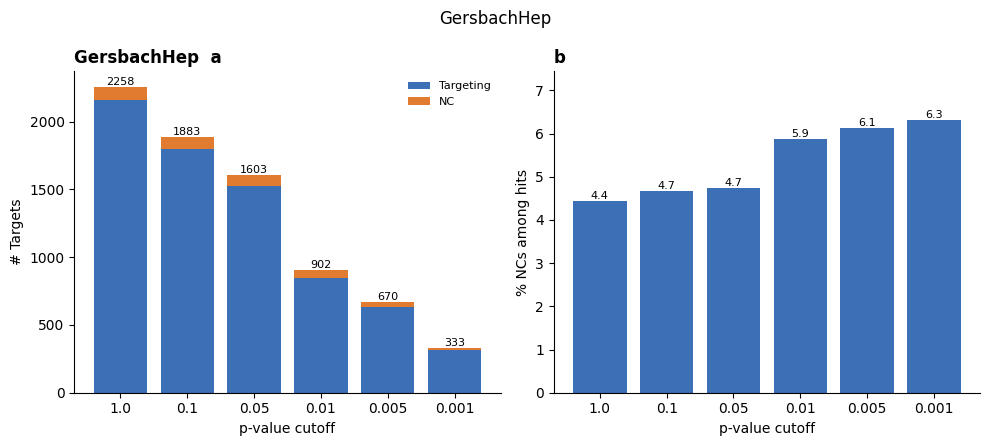

wrote cutoff_sweep_GersbachHep.{pdf,png}


In [5]:
CUTOFFS = [1.0, 0.1, 0.05, 0.01, 0.005, 0.001]

def cutoff_sweep_panel(df, title, ax1, ax2):
    is_nc = df["type"] == "negative control"
    n_total  = np.array([(df["pval_mean"] < c).sum() for c in CUTOFFS])
    n_nc     = np.array([((df["pval_mean"] < c) & is_nc).sum() for c in CUTOFFS])
    n_target = n_total - n_nc
    with np.errstate(divide="ignore", invalid="ignore"):
        pct_nc = np.where(n_total > 0, 100 * n_nc / n_total, 0)
    x = np.arange(len(CUTOFFS))

    ax1.bar(x, n_target, color="#3B6FB6", label="Targeting")
    ax1.bar(x, n_nc, bottom=n_target, color="#E07B30", label="NC")
    for xi, t in zip(x, n_total):
        ax1.text(xi, t, f"{t}", ha="center", va="bottom", fontsize=8)
    ax1.set_xticks(x); ax1.set_xticklabels([str(c) for c in CUTOFFS])
    ax1.set_xlabel("p-value cutoff"); ax1.set_ylabel("# Targets")
    ax1.set_title(f"{title}  a", loc="left", fontweight="bold")
    ax1.legend(frameon=False, fontsize=8)
    ax1.spines[["top", "right"]].set_visible(False)

    ax2.bar(x, pct_nc, color="#3B6FB6")
    for xi, p in zip(x, pct_nc):
        ax2.text(xi, p, f"{p:.1f}", ha="center", va="bottom", fontsize=8)
    ax2.set_xticks(x); ax2.set_xticklabels([str(c) for c in CUTOFFS])
    ax2.set_xlabel("p-value cutoff"); ax2.set_ylabel("% NCs among hits")
    ax2.set_title("b", loc="left", fontweight="bold")
    ax2.spines[["top", "right"]].set_visible(False)
    ax2.set_ylim(0, max(pct_nc.max() * 1.18, 5))

for short in DATASET_ORDER:
    sub = long[long["dataset_short"] == short]
    if sub.empty:
        continue
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4.5))
    cutoff_sweep_panel(sub, short, ax1, ax2)
    fig.suptitle(short)
    plt.tight_layout()
    for ext in ("pdf", "png"):
        out = OUT_DIR / f"cutoff_sweep_{short}.{ext}"
        fig.savefig(out, bbox_inches="tight")
    plt.show()
    print(f"wrote cutoff_sweep_{short}.{{pdf,png}}")


## Across-dataset cutoff sweep

Same panels — but bars grouped by cutoff and colored by dataset (production palette). Left: # significant targets; right: % NCs among hits.


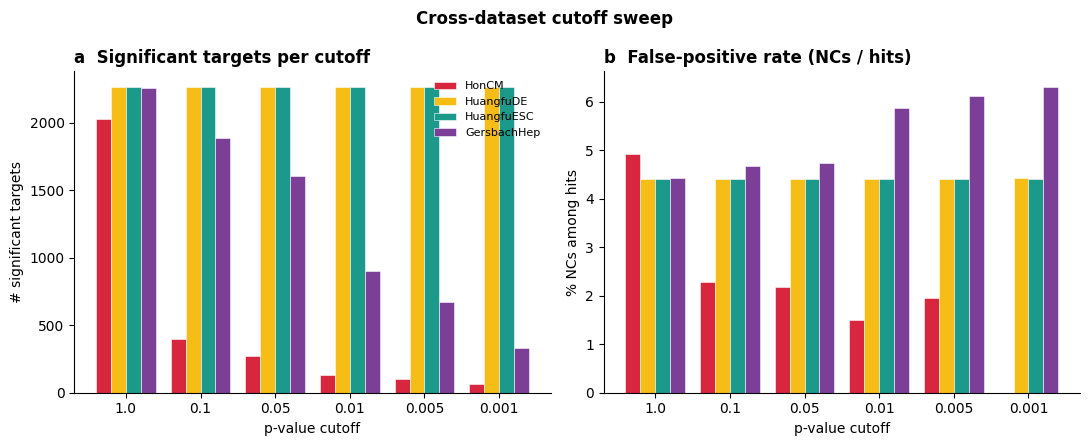

wrote cutoff_sweep_cross_dataset.{pdf,png}


In [6]:
def grouped_cutoff_sweep(ax_left, ax_right, *, datasets, cutoffs, df_long):
    n_ds = len(datasets)
    width = 0.8 / n_ds
    x = np.arange(len(cutoffs))

    for i, ds in enumerate(datasets):
        sub = df_long[df_long["dataset_short"] == ds]
        is_nc = sub["type"] == "negative control"
        n_total = np.array([(sub["pval_mean"] < c).sum() for c in cutoffs])
        n_nc    = np.array([((sub["pval_mean"] < c) & is_nc).sum() for c in cutoffs])
        with np.errstate(divide="ignore", invalid="ignore"):
            pct_nc = np.where(n_total > 0, 100 * n_nc / n_total, 0)
        offset = (i - (n_ds - 1) / 2) * width
        c = COLORS[ds]
        ax_left.bar(x + offset, n_total, width=width, color=c, label=ds, edgecolor="white", linewidth=0.4)
        ax_right.bar(x + offset, pct_nc, width=width, color=c, edgecolor="white", linewidth=0.4)

    for ax, ylabel, title in [(ax_left, "# significant targets", "a  Significant targets per cutoff"),
                              (ax_right, "% NCs among hits",     "b  False-positive rate (NCs / hits)")]:
        ax.set_xticks(x); ax.set_xticklabels([str(c) for c in cutoffs])
        ax.set_xlabel("p-value cutoff")
        ax.set_ylabel(ylabel)
        ax.set_title(title, loc="left", fontweight="bold")
        ax.spines[["top", "right"]].set_visible(False)
    ax_left.legend(frameon=False, fontsize=8, loc="upper right")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))
grouped_cutoff_sweep(ax1, ax2, datasets=DATASET_ORDER, cutoffs=CUTOFFS, df_long=long)
fig.suptitle("Cross-dataset cutoff sweep", fontweight="bold")
plt.tight_layout()
for ext in ("pdf", "png"):
    out = OUT_DIR / f"cutoff_sweep_cross_dataset.{ext}"
    fig.savefig(out, bbox_inches="tight")
plt.show()
print(f"wrote cutoff_sweep_cross_dataset.{{pdf,png}}")


## UpSet of shared significant TFs at each cutoff

Significance = `pval_mean < cutoff` on **targeting** entries only (NCs excluded). Keyed by `gene_symbol` when present, else `gene_id`. One panel per cutoff; the 1.0 cutoff is dropped because every target passes by definition.


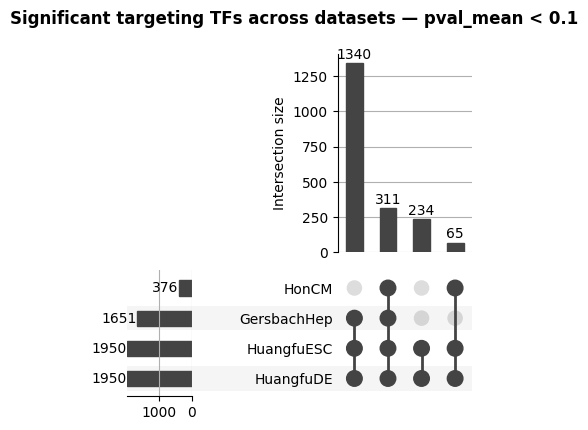

cutoff=0.1  per-dataset hits: HonCM=376, HuangfuDE=1950, HuangfuESC=1950, GersbachHep=1651


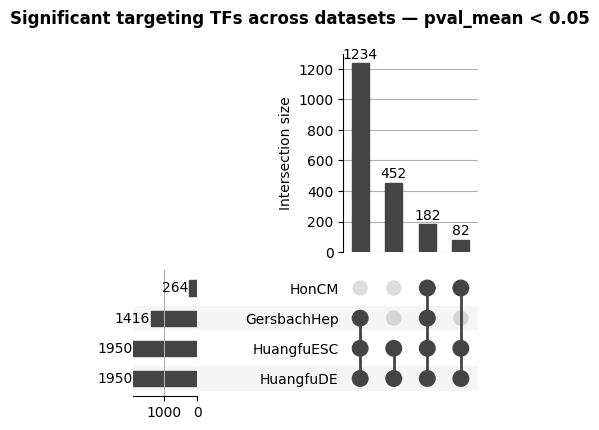

cutoff=0.05  per-dataset hits: HonCM=264, HuangfuDE=1950, HuangfuESC=1950, GersbachHep=1416


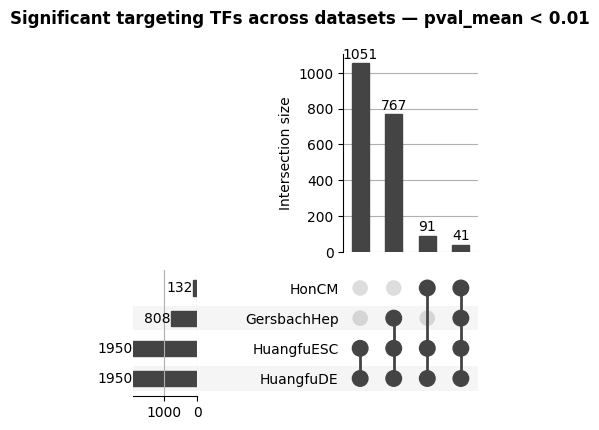

cutoff=0.01  per-dataset hits: HonCM=132, HuangfuDE=1950, HuangfuESC=1950, GersbachHep=808


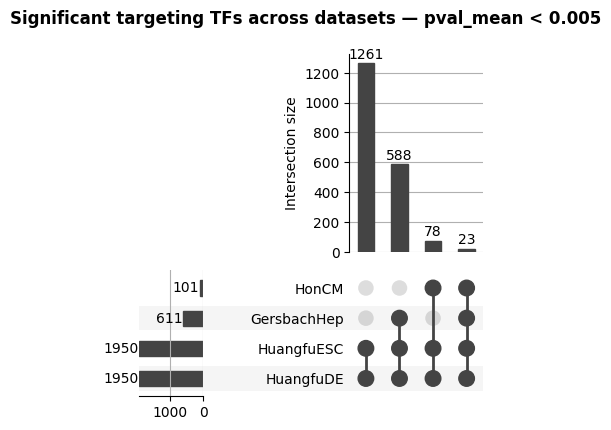

cutoff=0.005  per-dataset hits: HonCM=101, HuangfuDE=1950, HuangfuESC=1950, GersbachHep=611


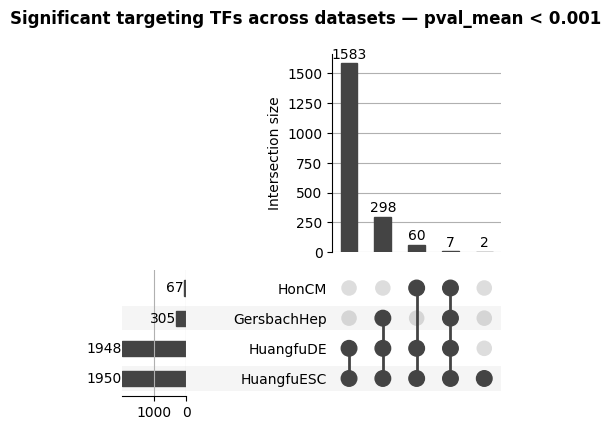

cutoff=0.001  per-dataset hits: HonCM=67, HuangfuDE=1948, HuangfuESC=1950, GersbachHep=305


In [7]:
from upsetplot import UpSet, from_contents

targeting = long[long["type"] != "negative control"].copy()
targeting["key"] = np.where(targeting["gene_symbol"] != "", targeting["gene_symbol"], targeting["gene_id"])

UPSET_CUTOFFS = [c for c in CUTOFFS if c < 1.0]

for cutoff in UPSET_CUTOFFS:
    hits = targeting[targeting["pval_mean"] < cutoff]
    contents = {ds: set(hits.loc[hits["dataset_short"] == ds, "key"]) for ds in DATASET_ORDER}
    sizes    = {ds: len(s) for ds, s in contents.items()}
    if sum(sizes.values()) == 0:
        print(f"  [skip] cutoff={cutoff}: no hits")
        continue

    fig = plt.figure(figsize=(8, 4.5))
    up = UpSet(from_contents(contents),
               sort_by="cardinality",
               show_counts=True,
               facecolor="#444")
    up.plot(fig=fig)
    fig.suptitle(f"Significant targeting TFs across datasets — pval_mean < {cutoff}", fontweight="bold")
    for ext in ("pdf", "png"):
        out = OUT_DIR / f"upset_pval_lt_{str(cutoff).replace('.', 'p')}.{ext}"
        fig.savefig(out, bbox_inches="tight")
    plt.show()
    print(f"cutoff={cutoff}  per-dataset hits: " + ", ".join(f"{k}={v}" for k, v in sizes.items()))
